In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import FuncFormatter

PATH = "Data/spotify_global_trends.csv"

def millions(x, pos):
    return f'{x/1e6:.1f}M'

In [165]:
df = pd.read_csv(PATH)
df.head()

,track_name,artist_name,streams,stream_change,7day,genre,country,pos,days,viral_score,trend,popularity_category,longevity
0,SWIM,BTS,11273830,-3370522,25918182,K-Pop,KR,1,2,37192012,Falling,Trending,New
1,Body to Body,BTS,6815694,-4369341,18000729,K-Pop,KR,2,2,24816423,Falling,Trending,New
2,Babydoll,Dominic Fike,5733862,178968,36599831,Alternative Pop,Florida,3,119,42333693,Rising,Trending,Evergreen
3,Hooligan,BTS,5338608,-3396855,14074071,K-Pop,KR,4,2,19412679,Falling,Trending,New
4,FYA,BTS,5196767,-2873904,13267438,K-Pop,KR,5,2,18464205,Falling,Trending,New


In [ ]:
df.info()



<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   track_name           178 non-null    str  
 1   artist_name          178 non-null    str  
 2   streams              178 non-null    int64
 3   stream_change        178 non-null    int64
 4   7day                 178 non-null    int64
 5   genre                178 non-null    str  
 6   country              178 non-null    str  
 7   pos                  178 non-null    int64
 8   days                 178 non-null    int64
 9   viral_score          178 non-null    int64
 10  trend                178 non-null    str  
 11  popularity_category  178 non-null    str  
 12  longevity            178 non-null    str  
dtypes: int64(6), str(7)
memory usage: 18.2 KB


In [ ]:
print(df.isnull().sum(),"\n")
df.duplicated().sum()

track_name             0
artist_name            0
streams                0
stream_change          0
7day                   0
genre                  0
country                0
pos                    0
days                   0
viral_score            0
trend                  0
popularity_category    0
longevity              0
dtype: int64 



np.int64(0)

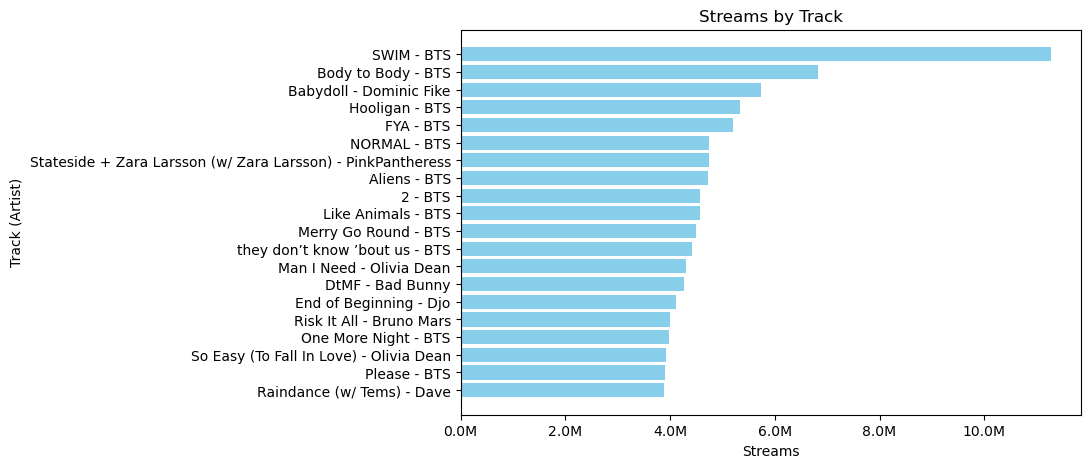

In [ ]:
df_sorted_streams = df.sort_values("streams", ascending=False).head(20)

df_sorted_streams["label"] = (
    df_sorted_streams["track_name"] + " - " + df_sorted_streams["artist_name"]
)

plt.figure(figsize=(8,5))
plt.barh(df_sorted_streams["label"], df_sorted_streams["streams"], color="skyblue")

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))


plt.title("Streams by Track")
plt.xlabel("Streams")
plt.ylabel("Track (Artist)")
plt.gca().invert_yaxis()  # highest at top
plt.show()


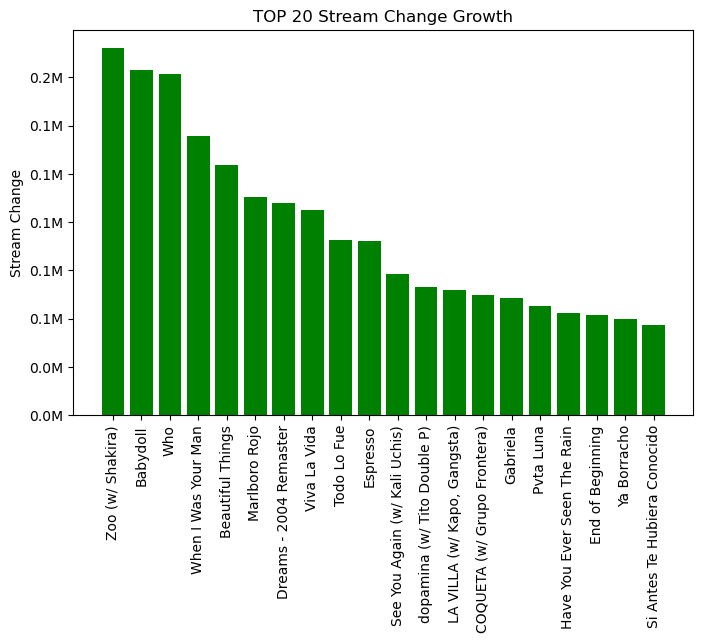

In [169]:

df_sorted_growth = df.sort_values("stream_change", ascending=False)
colors = ["green" if x > 0 else "red" for x in df_sorted_growth["stream_change"]]

df_sorted_growth = df_sorted_growth[:20]


plt.figure(figsize=(8,5))
plt.bar(df_sorted_growth["track_name"], df_sorted_growth["stream_change"], color=colors)

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))


plt.xticks(rotation=90)
plt.title("TOP 20 Stream Change Growth")
plt.ylabel("Stream Change")
plt.show()

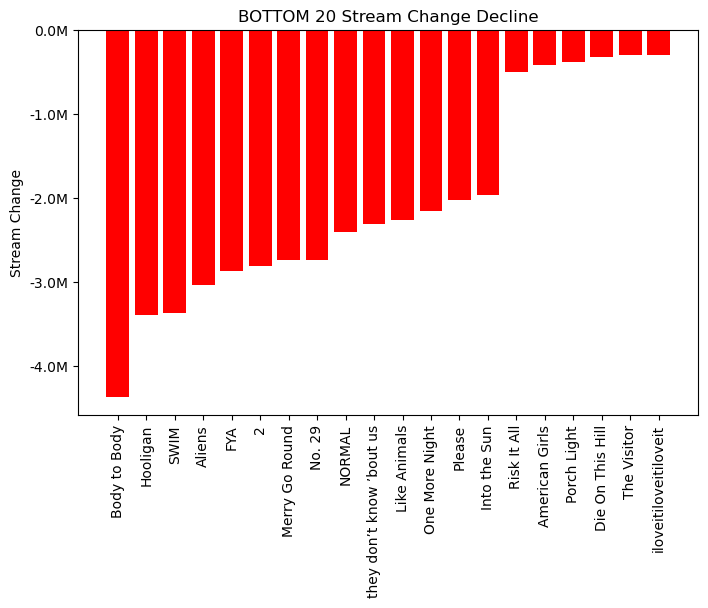

In [170]:

df_sorted_decline = df.sort_values("stream_change", ascending=True)
colors = ["green" if x > 0 else "red" for x in df_sorted_decline["stream_change"]]

df_sorted_decline = df_sorted_decline[:20]


plt.figure(figsize=(8,5))
plt.bar(df_sorted_decline["track_name"], df_sorted_decline["stream_change"], color=colors)

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))


plt.xticks(rotation=90)
plt.title("BOTTOM 20 Stream Change Decline")
plt.ylabel("Stream Change")
plt.show()

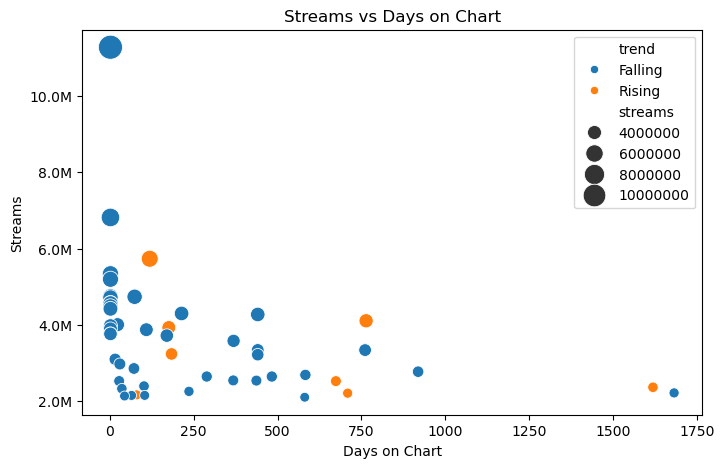

In [171]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df[:50],
    x="days",
    y="streams",
    hue="trend",
    size="streams",
    sizes=(50, 300)
)
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.title("Streams vs Days on Chart")
plt.xlabel("Days on Chart")
plt.ylabel("Streams")
plt.show()

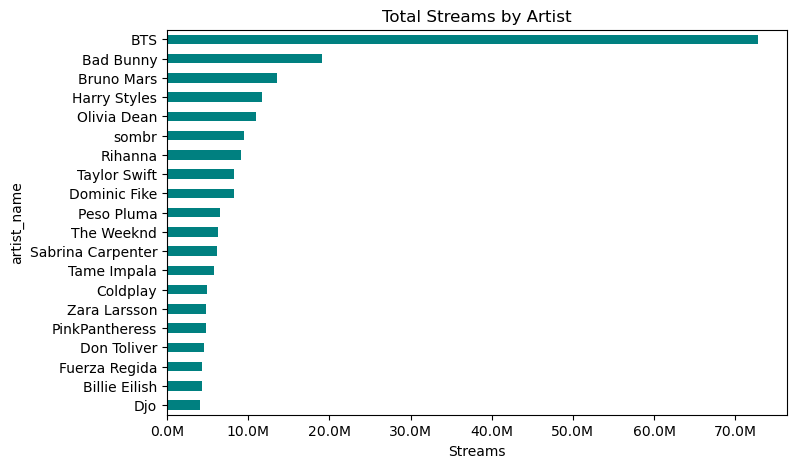

In [172]:

top_artists = (
    df.groupby("artist_name")["streams"]
      .sum()
      .sort_values(ascending=False)
      .head(20)         
      .sort_values()    
)

top_artists.plot(kind="barh", figsize=(8,5), color="teal")
plt.title("Total Streams by Artist")
plt.xlabel("Streams")
plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
plt.show()

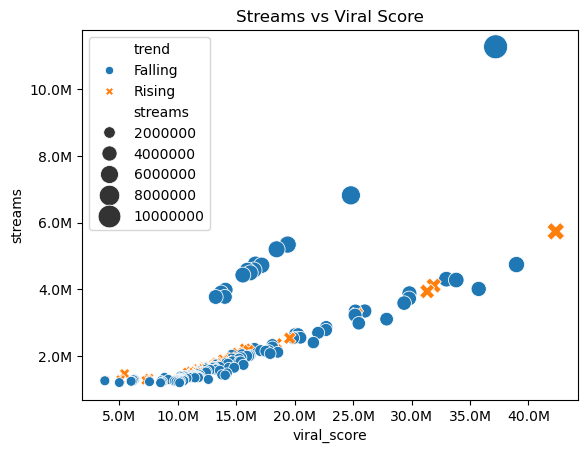

In [173]:
from numpy import shape


sns.scatterplot(
    data=df,
    x="viral_score",
    y="streams",
    hue="trend",
    size="streams",
    style = "trend",
    sizes=(50, 300)
)

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.title("Streams vs Viral Score")
plt.show()

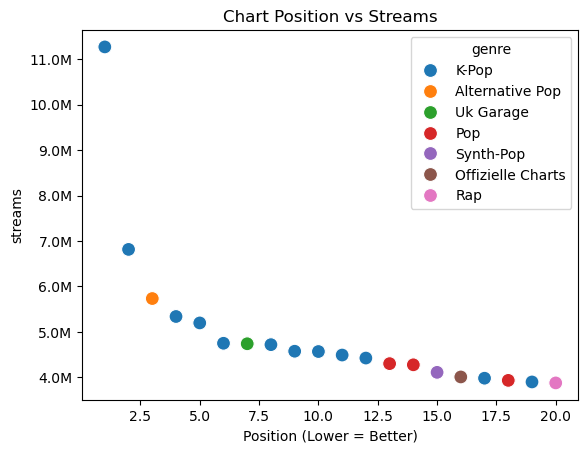

In [174]:
sns.scatterplot(data=df_sorted_streams, x="pos", y="streams", hue="genre", s=100)

plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.title("Chart Position vs Streams")
plt.xlabel("Position (Lower = Better)")
plt.show()

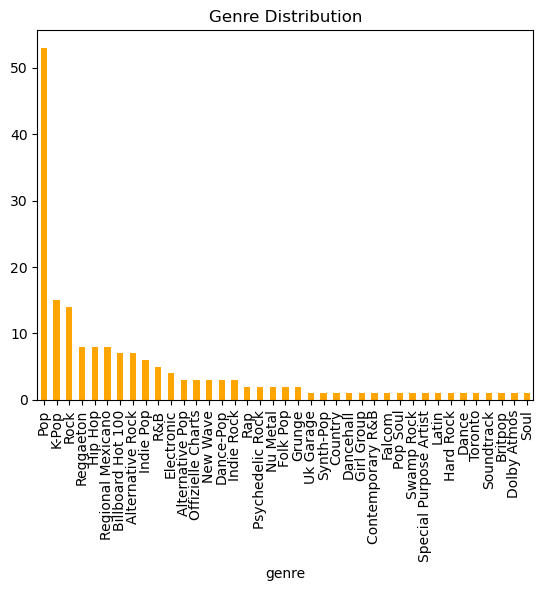

In [175]:
df["genre"].value_counts().plot(kind="bar", color="orange")
plt.title("Genre Distribution")
plt.show()

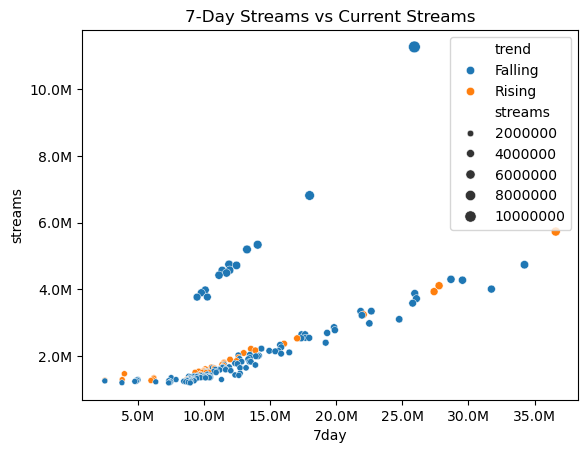

In [176]:
sns.scatterplot(data=df, x="7day", y="streams", hue="trend", size="streams")

plt.gca().xaxis.set_major_formatter(FuncFormatter(millions))
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

plt.title("7-Day Streams vs Current Streams")
plt.show()

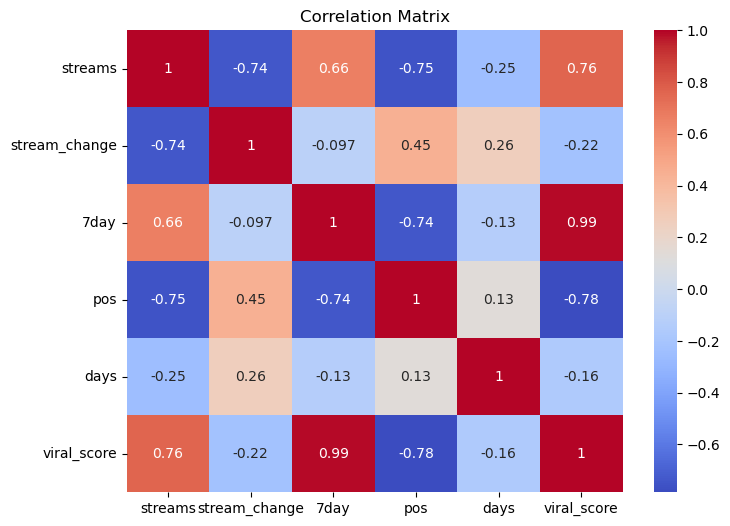

In [177]:
num_df = df.select_dtypes(include="number")

plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()